#  Chicago Crime Analysis — ML Pipeline 2 Étapes

## Contexte Business
La ville de Chicago enregistre **+200 000 crimes par an**. Notre système reproduit le raisonnement d'un dispatcheur de police en **deux étapes** :

> *"Avant de savoir si un crime va être résolu, il faut d'abord identifier quel type de crime s'est produit."*

```
ÉTAPE 0 → K-Means          : Identifier la zone géographique (non supervisé)
ÉTAPE 1 → Random Forest     : Prédire le TYPE de crime (supervisé multiclass)  
ÉTAPE 2 → XGBoost optimisé  : Prédire l'ARRESTATION en utilisant le résultat de l'étape 1
```

| | |
|---|---|
| **Dataset** | Chicago Data Portal — Crimes 2022–2026 (COVID → aujourd'hui) |
| **Source** | https://data.cityofchicago.org/resource/ijzp-q8t2.csv |
| **Volume** | ~200 000 lignes |


## 📅 Périmètre Temporel : 2022 → 2026 (Post-COVID)

On exclut volontairement la période COVID (2020–2021) car elle représente une **anomalie statistique** qui biaiserait nos modèles :

| Période exclue | Raison |
|---|---|
| 2020–2021 | Lockdowns → comportements criminels atypiques, données non représentatives |

Notre dataset couvre **2022 → 2026**, soit une période **normale et récente** :

| Période | Contexte |
|---|---|
| 2022 | Retour à la normale post-COVID |
| 2023–2024 | Stabilisation, nouvelles tendances |
| 2025–2026 | Données les plus récentes disponibles |

> *"On choisit d'exclure le COVID car entraîner un modèle sur des données atypiques produirait des prédictions biaisées pour la période actuelle."*


In [3]:
! pip install xgboost --quiet

##  0 — Imports

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib requests --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests, warnings, joblib, os
from io import StringIO

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
RANDOM_STATE = 42
print(' Imports OK')


 Imports OK


##  1 — Chargement des Données

In [2]:
URL = 'https://data.cityofchicago.org/resource/ijzp-q8t2.csv'
PARAMS = {'$limit': 200000, '$order': 'date DESC', '$where': 'year >= 2022 AND year <= 2026'}

print(' Chargement depuis l\'API Chicago...')
try:
    r = requests.get(URL, params=PARAMS, timeout=120)
    r.raise_for_status()
    df_raw = pd.read_csv(StringIO(r.text), low_memory=False)
    print(f' {len(df_raw):,} lignes chargées')
except Exception as e:
    print(f' Erreur : {e}')
    df_raw = pd.read_csv(
        'https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=200000&$where=year>=2022',
        low_memory=False
    )
print(f'Shape : {df_raw.shape}')
df_raw.head(3)


 Chargement depuis l'API Chicago...
 200,000 lignes chargées
Shape : (200000, 22)


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14193193,JK249780,2026-05-07T00:00:00.000,057XX S MASSASOIT AVE,0820,THEFT,$500 AND UNDER,STREET,False,False,...,13.0,56.0,06,1139027.0,1865902.0,2026,2026-05-14T15:42:45.000,41.788146,-87.765788,"\n, \n(41.788146448, -87.7657879)"
1,14189343,JK244991,2026-05-07T00:00:00.000,037XX S KEDZIE AVE,0520,ASSAULT,AGGRAVATED - KNIFE / CUTTING INSTRUMENT,STREET,False,False,...,12.0,58.0,04A,1155651.0,1879447.0,2026,2026-05-14T15:42:45.000,41.824998,-87.704470,"\n, \n(41.824998461, -87.704470011)"
2,14190162,JK245267,2026-05-07T00:00:00.000,035XX N NEWCASTLE AVE,0710,THEFT,THEFT FROM MOTOR VEHICLE,STREET,False,False,...,38.0,17.0,06,1130115.0,1922819.0,2026,2026-05-14T15:42:45.000,41.944492,-87.797162,"\n, \n(41.944492153, -87.797162077)"


##  2 — Exploration des Données (EDA)

In [3]:
print('='*60)
print('  STATISTIQUES GÉNÉRALES — CHICAGO CRIMES 2022-2024')
print('='*60)
print(f'  Lignes          : {len(df_raw):,}')
print(f'  Types de crimes : {df_raw["primary_type"].nunique()}')
print(f'  Arrestations    : {df_raw["arrest"].sum():,} ({df_raw["arrest"].mean()*100:.1f}%)')
print(f'  Crimes domestic : {df_raw["domestic"].sum():,} ({df_raw["domestic"].mean()*100:.1f}%)')
print()
missing = df_raw.isnull().sum()
print('Valeurs manquantes :')
print(missing[missing > 0].sort_values(ascending=False))


  STATISTIQUES GÉNÉRALES — CHICAGO CRIMES 2022-2024
  Lignes          : 200,000
  Types de crimes : 30
  Arrestations    : 30,479 (15.2%)
  Crimes domestic : 37,859 (18.9%)

Valeurs manquantes :
location_description    1011
x_coordinate              96
y_coordinate              96
latitude                  96
longitude                 96
location                  96
community_area             8
ward                       1
dtype: int64


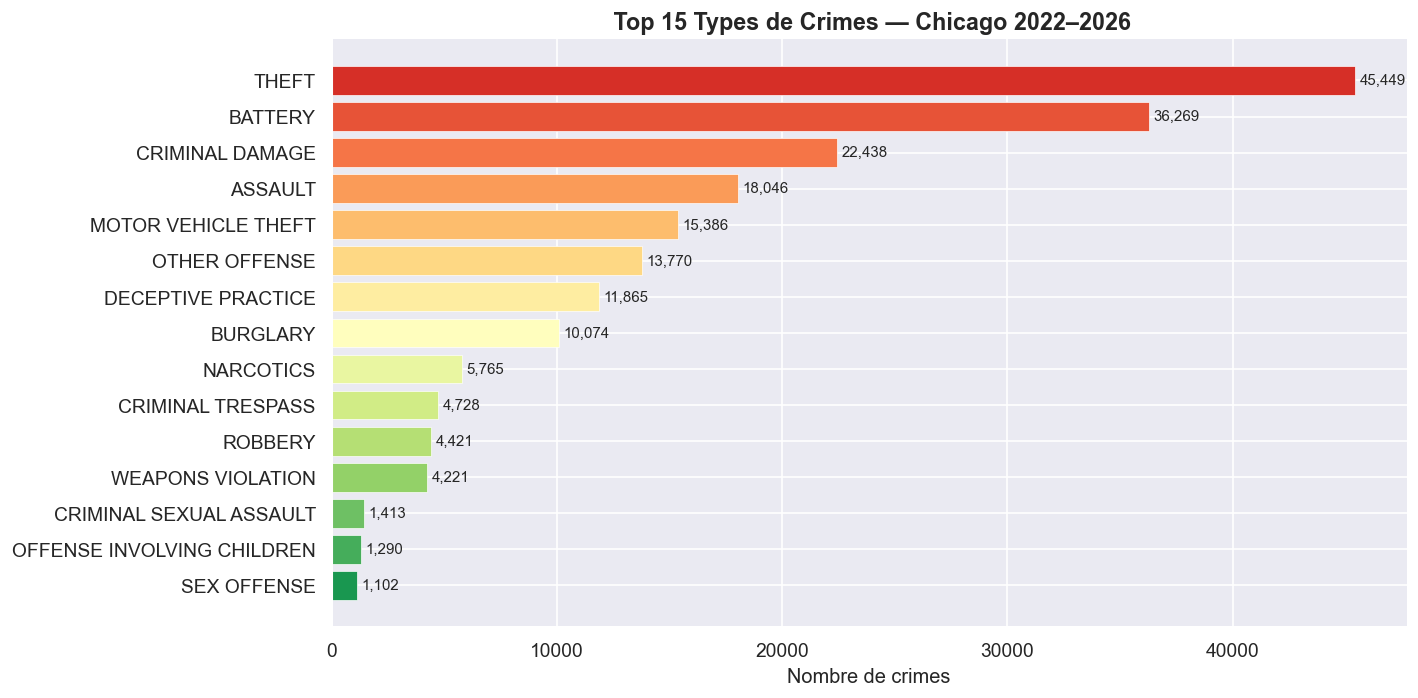

In [4]:
# ── VIZ 1 : Top 15 types de crimes ──
top15 = df_raw['primary_type'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 15))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors, edgecolor='white', lw=0.4)
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Nombre de crimes', fontsize=12)
ax.set_title(' Top 15 Types de Crimes — Chicago 2022–2026', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('viz_01_top15.png', bbox_inches='tight'); plt.show()


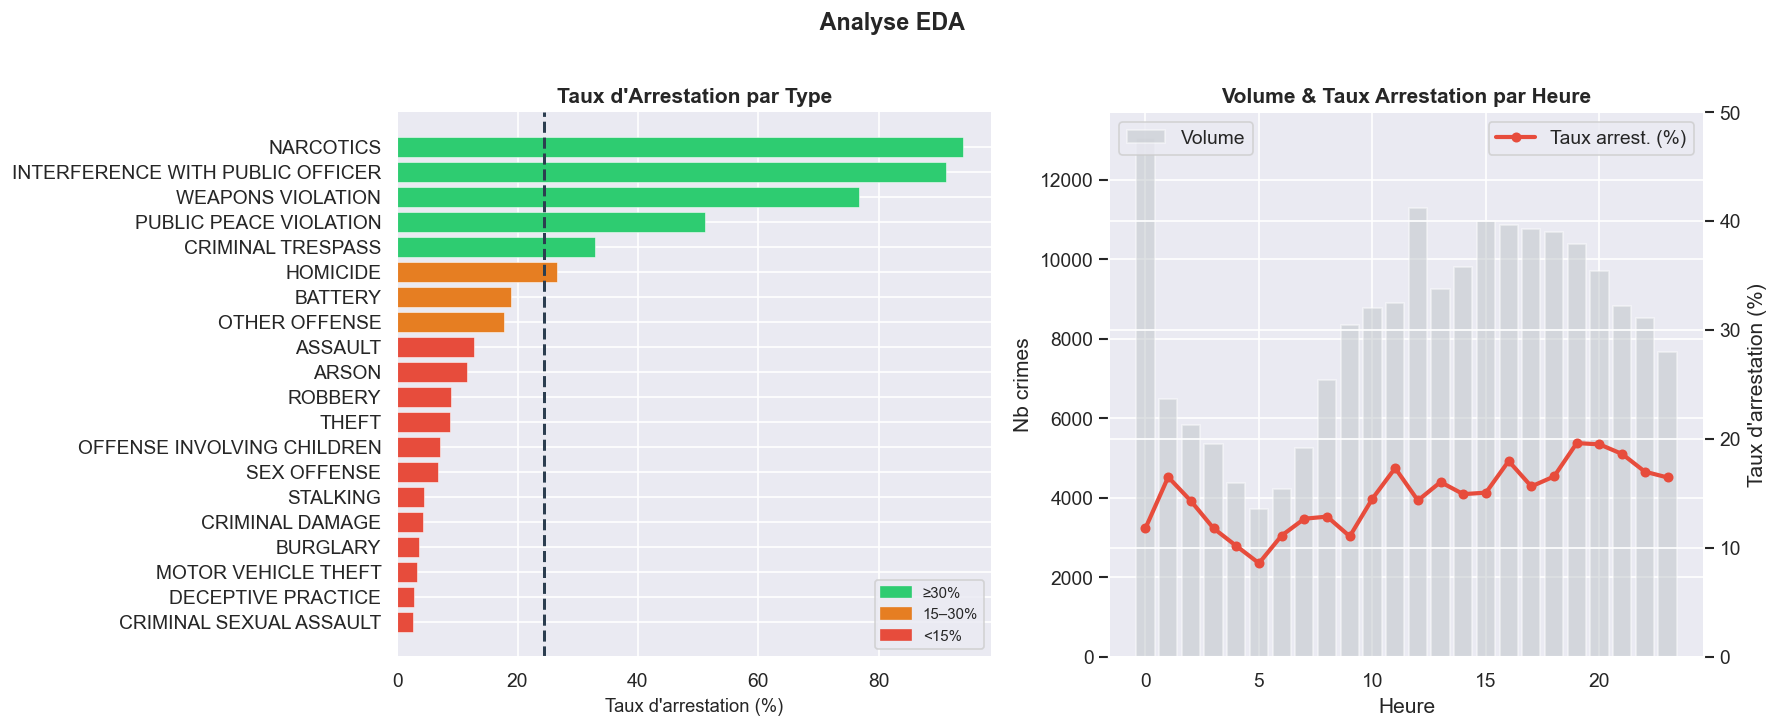

In [5]:
# ── VIZ 2 : Taux d'arrestation par type ──
df_raw['date_parsed'] = pd.to_datetime(df_raw['date'], errors='coerce')
df_raw['hour']        = df_raw['date_parsed'].dt.hour
df_raw['day_of_week'] = df_raw['date_parsed'].dt.dayofweek
df_raw['month']       = df_raw['date_parsed'].dt.month

arrest_by_type = (
    df_raw.groupby('primary_type')['arrest']
    .agg(['mean','count']).query('count > 200')
    .sort_values('mean', ascending=False).head(20)
)
avg = arrest_by_type['mean'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = ['#2ecc71' if v>=0.30 else '#e67e22' if v>=0.15 else '#e74c3c'
           for v in arrest_by_type['mean'].values]
axes[0].barh(arrest_by_type.index[::-1], arrest_by_type['mean'].values[::-1]*100,
             color=palette[::-1], edgecolor='white', lw=0.3)
axes[0].axvline(x=avg*100, color='#2c3e50', linestyle='--', lw=1.8,
                label=f'Moyenne : {avg*100:.1f}%')
axes[0].set_xlabel("Taux d'arrestation (%)", fontsize=11)
axes[0].set_title("Taux d'Arrestation par Type", fontweight='bold')
patches = [mpatches.Patch(color='#2ecc71',label='≥30%'),
           mpatches.Patch(color='#e67e22',label='15–30%'),
           mpatches.Patch(color='#e74c3c',label='<15%')]
axes[0].legend(handles=patches, fontsize=9, loc='lower right')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Heure
hour_rate = df_raw.groupby('hour')['arrest'].mean()*100
hour_vol  = df_raw.groupby('hour').size()
ax2 = axes[1].twinx()
axes[1].bar(range(24), hour_vol.values, color='#bdc3c7', alpha=0.5, label='Volume')
ax2.plot(range(24), hour_rate.values, 'o-', color='#e74c3c', lw=2.5, ms=5, label="Taux arrest. (%)")
axes[1].set_xlabel('Heure'); axes[1].set_ylabel('Nb crimes')
ax2.set_ylabel("Taux d'arrestation (%)"); ax2.set_ylim(0,50)
axes[1].set_title("Volume & Taux Arrestation par Heure", fontweight='bold')
axes[1].legend(loc='upper left'); ax2.legend(loc='upper right')

plt.suptitle(' Analyse EDA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('viz_02_eda.png', bbox_inches='tight'); plt.show()


##  3 — Nettoyage & Feature Engineering

In [6]:
df = df_raw.copy()
before = len(df)
df = df.dropna(subset=['latitude','longitude','arrest','primary_type'])
df = df[(df['latitude'] != 0) & (df['longitude'] != 0)]
print(f' {before:,} → {len(df):,} lignes')

df['arrest']     = df['arrest'].astype(bool).astype(int)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['domestic']   = df['domestic'].astype(bool).astype(int)

# Encoder la cible Step 1 (type de crime) — garder les TOP 10 + "OTHER"
top10_crimes = df['primary_type'].value_counts().head(10).index.tolist()
df['crime_cat'] = df['primary_type'].apply(lambda x: x if x in top10_crimes else 'OTHER')

le_crime = LabelEncoder()
df['crime_encoded'] = le_crime.fit_transform(df['crime_cat'])

def location_group(loc):
    if pd.isna(loc): return 5
    loc = str(loc).upper()
    if any(w in loc for w in ['STREET','ALLEY','SIDEWALK','PARKING']): return 0
    if any(w in loc for w in ['RESIDENCE','APARTMENT','HOUSE']): return 1
    if any(w in loc for w in ['STORE','RESTAURANT','BANK','RETAIL','GAS']): return 2
    if any(w in loc for w in ['CTA','BUS','TRAIN','VEHICLE']): return 3
    if any(w in loc for w in ['PARK','SCHOOL','CHURCH','HOSPITAL']): return 4
    return 5

df['location_group'] = df['location_description'].apply(location_group)

print(f'\n Répartition arrests : {df["arrest"].mean()*100:.1f}% oui / {(1-df["arrest"].mean())*100:.1f}% non')
print(f' Types de crimes (groupés) : {df["crime_cat"].nunique()}')
print(df['crime_cat'].value_counts())


 200,000 → 199,904 lignes

 Répartition arrests : 15.2% oui / 84.8% non
 Types de crimes (groupés) : 11
crime_cat
THEFT                  45422
BATTERY                36266
CRIMINAL DAMAGE        22433
ASSAULT                18042
OTHER                  16203
MOTOR VEHICLE THEFT    15377
OTHER OFFENSE          13763
DECEPTIVE PRACTICE     11840
BURGLARY               10068
NARCOTICS               5765
CRIMINAL TRESPASS       4725
Name: count, dtype: int64


##  ÉTAPE 0 — K-Means : Identification des Zones

**Rôle dans le pipeline :** Le cluster géographique devient une **feature** pour les deux modèles supervisés.

**Justification :** Sans supervision, K-Means identifie naturellement les zones homogènes de Chicago — chaque zone a son propre profil de criminalité et son taux d'arrestation.


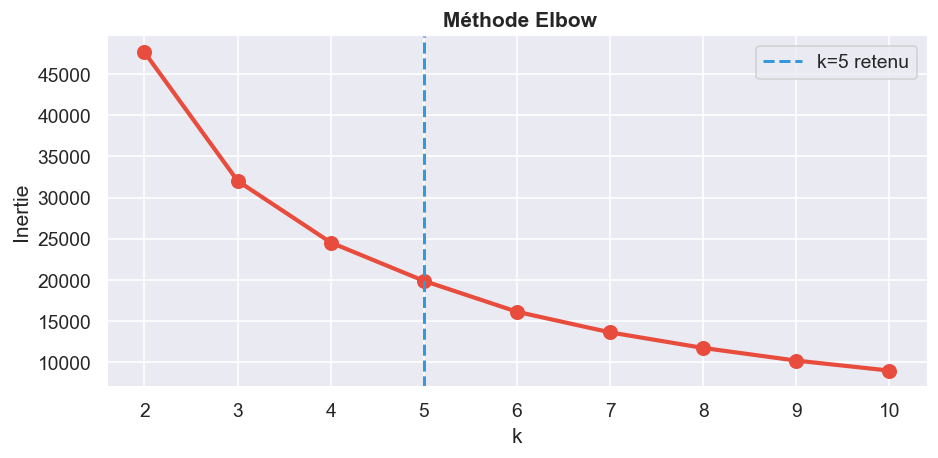

 K-Means OK — 5 clusters identifiés
cluster
0    160981
1     12087
2     11027
3      7631
4      8178
Name: count, dtype: int64


In [7]:
coords = df[['latitude','longitude']].sample(min(50000, len(df)), random_state=RANDOM_STATE)
scaler_kmeans = StandardScaler()
X_spatial = scaler_kmeans.fit_transform(coords)

# Elbow
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=5)
    inertias.append(km.fit(X_spatial).inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2,11), inertias, 'o-', color='#e74c3c', lw=2.5, ms=8)
ax.axvline(x=5, color='#3498db', linestyle='--', lw=1.8, label='k=5 retenu')
ax.set_xlabel('k'); ax.set_ylabel('Inertie')
ax.set_title(' Méthode Elbow', fontweight='bold')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('viz_03_elbow.png', bbox_inches='tight'); plt.show()

K = 5
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_spatial)
coords_copy = coords.copy()
coords_copy['cluster'] = kmeans.labels_
df = df.merge(coords_copy[['cluster']], left_index=True, right_index=True, how='left')
df['cluster'] = df['cluster'].fillna(0).astype(int)
print(f' K-Means OK — {K} clusters identifiés')
print(df['cluster'].value_counts().sort_index())


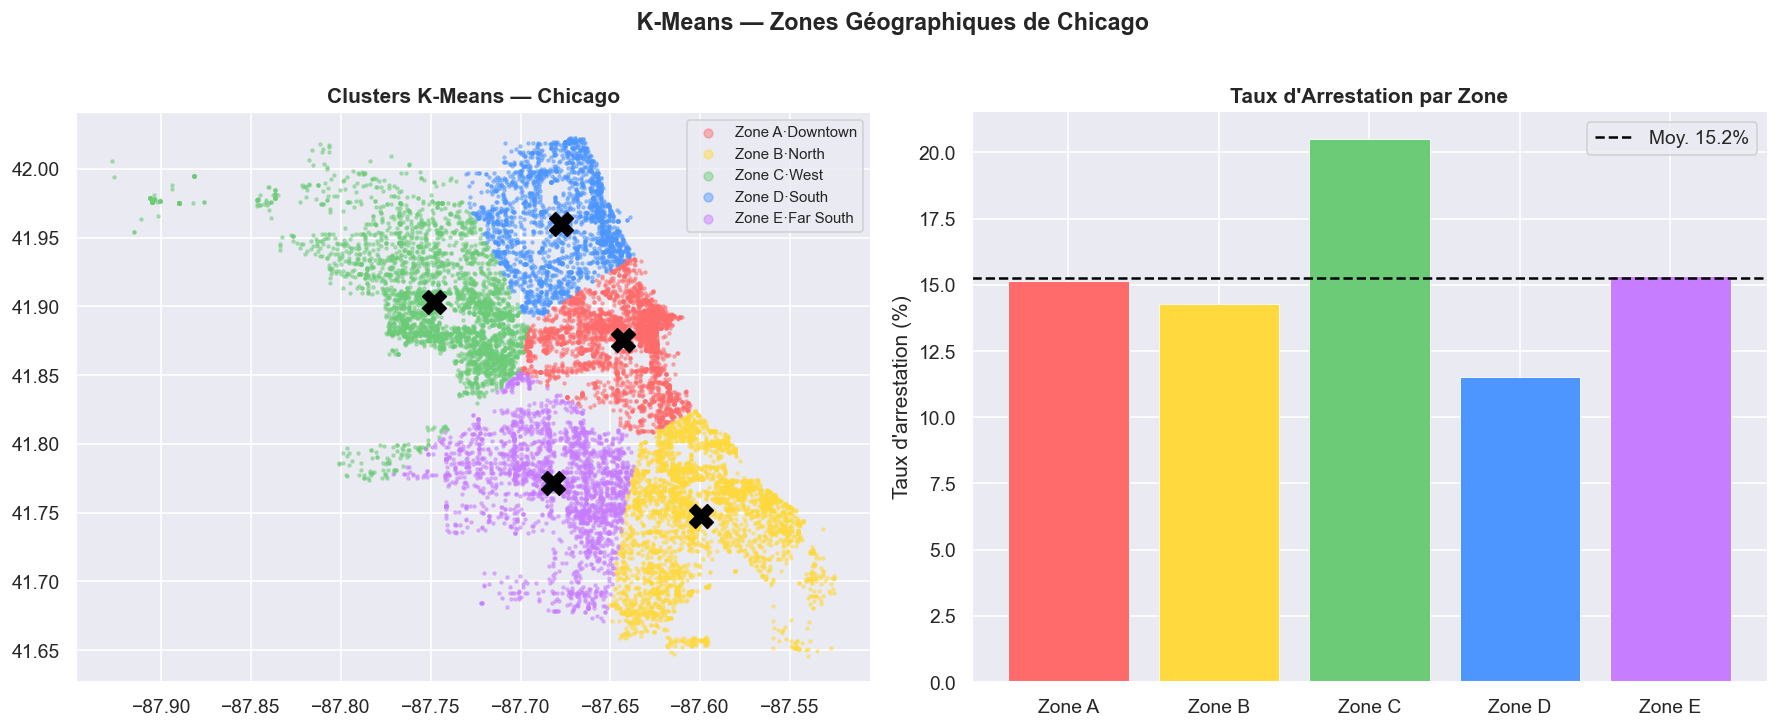

In [8]:
# ── VIZ : Clusters + profil ──
COLORS = ['#FF6B6B','#FFD93D','#6BCB77','#4D96FF','#C77DFF']
LABELS = ['Zone A·Downtown','Zone B·North','Zone C·West','Zone D·South','Zone E·Far South']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sample = df.dropna(subset=['latitude','longitude']).sample(min(15000,len(df)), random_state=42)
for c in range(K):
    m = sample['cluster']==c
    axes[0].scatter(sample.loc[m,'longitude'], sample.loc[m,'latitude'],
                    c=COLORS[c], s=3, alpha=0.45, label=LABELS[c])
cents = scaler_kmeans.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(cents[:,1], cents[:,0], c='black', s=200, marker='X', zorder=10)
axes[0].set_title('Clusters K-Means — Chicago', fontweight='bold')
axes[0].legend(fontsize=9, markerscale=3)

arrest_cl = df.groupby('cluster')['arrest'].mean()*100
axes[1].bar([f'Zone {chr(65+i)}' for i in range(K)], arrest_cl.values,
            color=COLORS, edgecolor='white', lw=0.5)
axes[1].axhline(y=df['arrest'].mean()*100, color='black', linestyle='--', lw=1.5,
                label=f"Moy. {df['arrest'].mean()*100:.1f}%")
axes[1].set_ylabel("Taux d'arrestation (%)"); axes[1].legend()
axes[1].set_title("Taux d'Arrestation par Zone", fontweight='bold')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle(' K-Means — Zones Géographiques de Chicago', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('viz_04_kmeans.png', bbox_inches='tight'); plt.show()


##  ÉTAPE 1 — Random Forest : Prédiction du Type de Crime

**Objectif :** À partir du contexte (heure, lieu, zone), prédire quel type de crime s'est produit.

**Justification Random Forest :** Tâche multiclass avec features hétérogènes — RF gère nativement ce cas sans normalisation. L'importance des features nous donnera des insights sur ce qui distingue les types de crimes.

**Features :** heure, jour, mois, weekend, zone K-Means, type de lieu, coordonnées  
**Cible :** type de crime (10 catégories + OTHER)


In [9]:
FEAT_STEP1 = ['latitude','longitude','hour','day_of_week','month',
              'is_weekend','cluster','location_group']
TARGET_STEP1 = 'crime_encoded'

df_s1 = df[FEAT_STEP1 + [TARGET_STEP1]].dropna()
X1 = df_s1[FEAT_STEP1]
y1 = df_s1[TARGET_STEP1]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.20, random_state=RANDOM_STATE, stratify=y1
)

print(f'Dataset Step 1 : {len(df_s1):,} lignes')
print(f'Train : {len(X1_train):,} | Test : {len(X1_test):,}')
print(f'Classes : {le_crime.classes_}')


Dataset Step 1 : 199,904 lignes
Train : 159,923 | Test : 39,981
Classes : ['ASSAULT' 'BATTERY' 'BURGLARY' 'CRIMINAL DAMAGE' 'CRIMINAL TRESPASS'
 'DECEPTIVE PRACTICE' 'MOTOR VEHICLE THEFT' 'NARCOTICS' 'OTHER'
 'OTHER OFFENSE' 'THEFT']


In [10]:
print(' Entraînement Random Forest — Prédiction type de crime...')

rf_crime = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_crime.fit(X1_train, y1_train)

y1_pred = rf_crime.predict(X1_test)
acc_s1 = accuracy_score(y1_test, y1_pred)
f1_s1  = f1_score(y1_test, y1_pred, average='weighted')

print(f'\n STEP 1 — Random Forest (Crime Type) :')
print(f'   Accuracy  : {acc_s1*100:.2f}%')
print(f'   F1-Score  : {f1_s1*100:.2f}%')
print()
print(classification_report(y1_test, y1_pred, target_names=le_crime.classes_))


 Entraînement Random Forest — Prédiction type de crime...

 STEP 1 — Random Forest (Crime Type) :
   Accuracy  : 24.20%
   F1-Score  : 23.38%

                     precision    recall  f1-score   support

            ASSAULT       0.15      0.07      0.09      3608
            BATTERY       0.37      0.20      0.26      7253
           BURGLARY       0.19      0.29      0.23      2014
    CRIMINAL DAMAGE       0.32      0.04      0.07      4487
  CRIMINAL TRESPASS       0.06      0.16      0.09       945
 DECEPTIVE PRACTICE       0.20      0.44      0.27      2368
MOTOR VEHICLE THEFT       0.20      0.61      0.30      3075
          NARCOTICS       0.19      0.57      0.28      1153
              OTHER       0.22      0.07      0.11      3241
      OTHER OFFENSE       0.14      0.27      0.19      2753
              THEFT       0.63      0.28      0.39      9084

           accuracy                           0.24     39981
          macro avg       0.24      0.27      0.21     39981
 

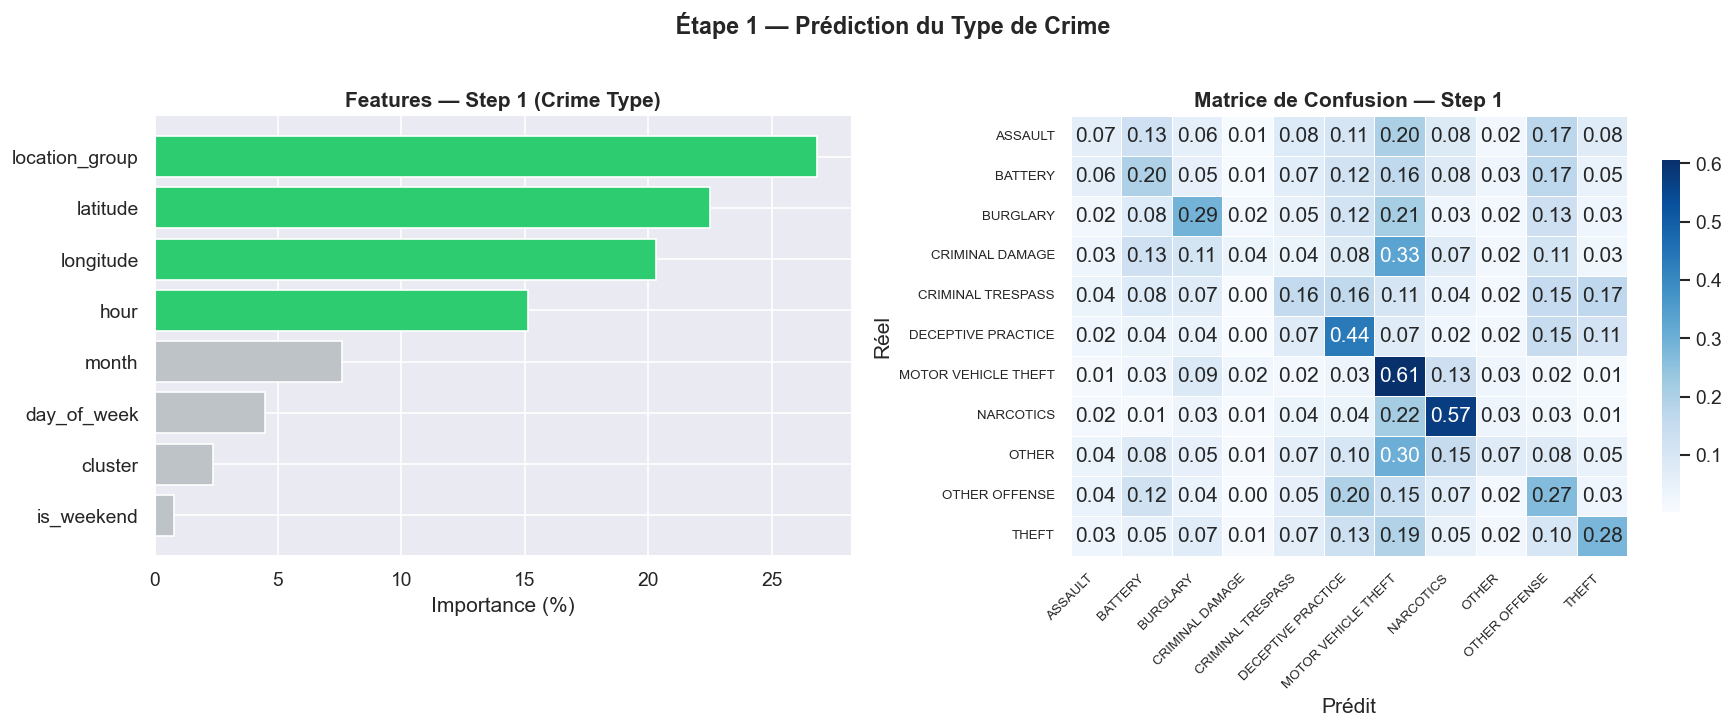

In [11]:
# ── VIZ : Feature importances Step 1 + Matrice de confusion ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

fi1 = pd.Series(rf_crime.feature_importances_, index=FEAT_STEP1).sort_values()
col1 = ['#2ecc71' if v > fi1.median() else '#bdc3c7' for v in fi1.values]
axes[0].barh(fi1.index, fi1.values*100, color=col1, edgecolor='white')
axes[0].set_xlabel('Importance (%)'); axes[0].set_title('Features — Step 1 (Crime Type)', fontweight='bold')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

cm1 = confusion_matrix(y1_test, y1_pred, normalize='true')
sns.heatmap(cm1, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=le_crime.classes_, yticklabels=le_crime.classes_,
            linewidths=0.3, cbar_kws={'shrink':0.8})
axes[1].set_title('Matrice de Confusion — Step 1', fontweight='bold')
axes[1].set_xlabel('Prédit'); axes[1].set_ylabel('Réel')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle(' Étape 1 — Prédiction du Type de Crime', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('viz_05_step1_rf.png', bbox_inches='tight'); plt.show()


##  ÉTAPE 2 — XGBoost optimisé : Prédiction de l'Arrestation

**Objectif :** Prédire si le crime va mener à une arrestation, en utilisant le **type de crime prédit à l'étape 1** comme feature supplémentaire.

**Justification XGBoost :** Boosting séquentiel — chaque arbre corrige les erreurs du précédent. Plus performant que RF sur les données tabulaires déséquilibrées.

**Optimisation :** `RandomizedSearchCV` sur les hyperparamètres clés — on cherche la meilleure combinaison sans tester exhaustivement toutes les possibilités.

**Features :** toutes les features Step 1 **+ crime prédit (Step 1) + domestic**  
**Cible :** arrest (0/1)


In [12]:
# ── Construire le dataset Step 2 avec le crime prédit ──
# On prédit le type de crime sur tout le dataset avec le modèle Step 1
df['crime_predicted'] = rf_crime.predict(df[FEAT_STEP1].fillna(0))

FEAT_STEP2 = ['latitude','longitude','hour','day_of_week','month',
              'is_weekend','domestic','cluster','location_group',
              'crime_predicted']   # ← type de crime prédit par Step 1
TARGET_STEP2 = 'arrest'

df_s2 = df[FEAT_STEP2 + [TARGET_STEP2]].dropna()
X2 = df_s2[FEAT_STEP2]
y2 = df_s2[TARGET_STEP2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=RANDOM_STATE, stratify=y2
)

print(f'Dataset Step 2 : {len(df_s2):,} lignes')
print(f'Train : {len(X2_train):,} | Test : {len(X2_test):,}')
print(f'Classe 0 (pas arrest) : {(y2==0).mean()*100:.1f}%')
print(f'Classe 1 (arrest)     : {(y2==1).mean()*100:.1f}%')
ratio = (y2_train==0).sum()/(y2_train==1).sum()
print(f'scale_pos_weight      : {ratio:.2f}')


Dataset Step 2 : 199,904 lignes
Train : 159,923 | Test : 39,981
Classe 0 (pas arrest) : 84.8%
Classe 1 (arrest)     : 15.2%
scale_pos_weight      : 5.56


In [13]:
# ══════════════════════════════════════════════
# RANDOMIZED SEARCH CV — Optimisation XGBoost
# ══════════════════════════════════════════════
print(' RandomizedSearchCV en cours (peut prendre 3-5 min)...')
print('   On cherche les meilleurs hyperparamètres sur 20 combinaisons')

param_dist = {
    'n_estimators':   [200, 300, 400],
    'max_depth':      [4, 5, 6, 7, 8],
    'learning_rate':  [0.01, 0.05, 0.08, 0.1],
    'subsample':      [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':          [0, 0.1, 0.2],
}

xgb_base = XGBClassifier(
    scale_pos_weight=ratio,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0, n_jobs=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=20,            # 20 combinaisons aléatoires
    scoring='roc_auc',    # optimiser l'AUC
    cv=cv,
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=-1
)

# Entraîner sur un sample pour la recherche (plus rapide)
sample_idx = X2_train.sample(min(30000, len(X2_train)), random_state=RANDOM_STATE).index
search.fit(X2_train.loc[sample_idx], y2_train.loc[sample_idx])

print(f'\n Meilleurs paramètres trouvés :')
for k, v in search.best_params_.items():
    print(f'   {k:<22} : {v}')
print(f'\n   Meilleur AUC (CV) : {search.best_score_:.4f}')


 RandomizedSearchCV en cours (peut prendre 3-5 min)...
   On cherche les meilleurs hyperparamètres sur 20 combinaisons
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Meilleurs paramètres trouvés :
   subsample              : 0.7
   n_estimators           : 400
   min_child_weight       : 5
   max_depth              : 7
   learning_rate          : 0.01
   gamma                  : 0.1
   colsample_bytree       : 0.7

   Meilleur AUC (CV) : 0.7052


In [14]:
# ── Entraîner le XGBoost final avec les meilleurs params ──
print(' Entraînement XGBoost final avec paramètres optimisés...')

best_params = search.best_params_.copy()
best_params['scale_pos_weight'] = ratio
best_params['random_state']     = RANDOM_STATE
best_params['eval_metric']      = 'logloss'
best_params['verbosity']        = 0
best_params['n_jobs']           = -1

xgb_best = XGBClassifier(**best_params)
xgb_best.fit(X2_train, y2_train,
             eval_set=[(X2_test, y2_test)], verbose=False)

y2_pred = xgb_best.predict(X2_test)
y2_prob = xgb_best.predict_proba(X2_test)[:,1]

acc_s2  = accuracy_score(y2_test, y2_pred)
f1_s2   = f1_score(y2_test, y2_pred, average='weighted')
auc_s2  = roc_auc_score(y2_test, y2_prob)

print(f'\n STEP 2 — XGBoost Optimisé (Arrestation) :')
print(f'   Accuracy  : {acc_s2*100:.2f}%')
print(f'   F1-Score  : {f1_s2*100:.2f}%')
print(f'   ROC-AUC   : {auc_s2:.4f}')
print()
print(classification_report(y2_test, y2_pred, target_names=["Pas d'arrest.","Arrestation"]))


 Entraînement XGBoost final avec paramètres optimisés...

 STEP 2 — XGBoost Optimisé (Arrestation) :
   Accuracy  : 68.96%
   F1-Score  : 73.02%
   ROC-AUC   : 0.7300

               precision    recall  f1-score   support

Pas d'arrest.       0.91      0.70      0.79     33885
  Arrestation       0.27      0.63      0.38      6096

     accuracy                           0.69     39981
    macro avg       0.59      0.67      0.59     39981
 weighted avg       0.82      0.69      0.73     39981



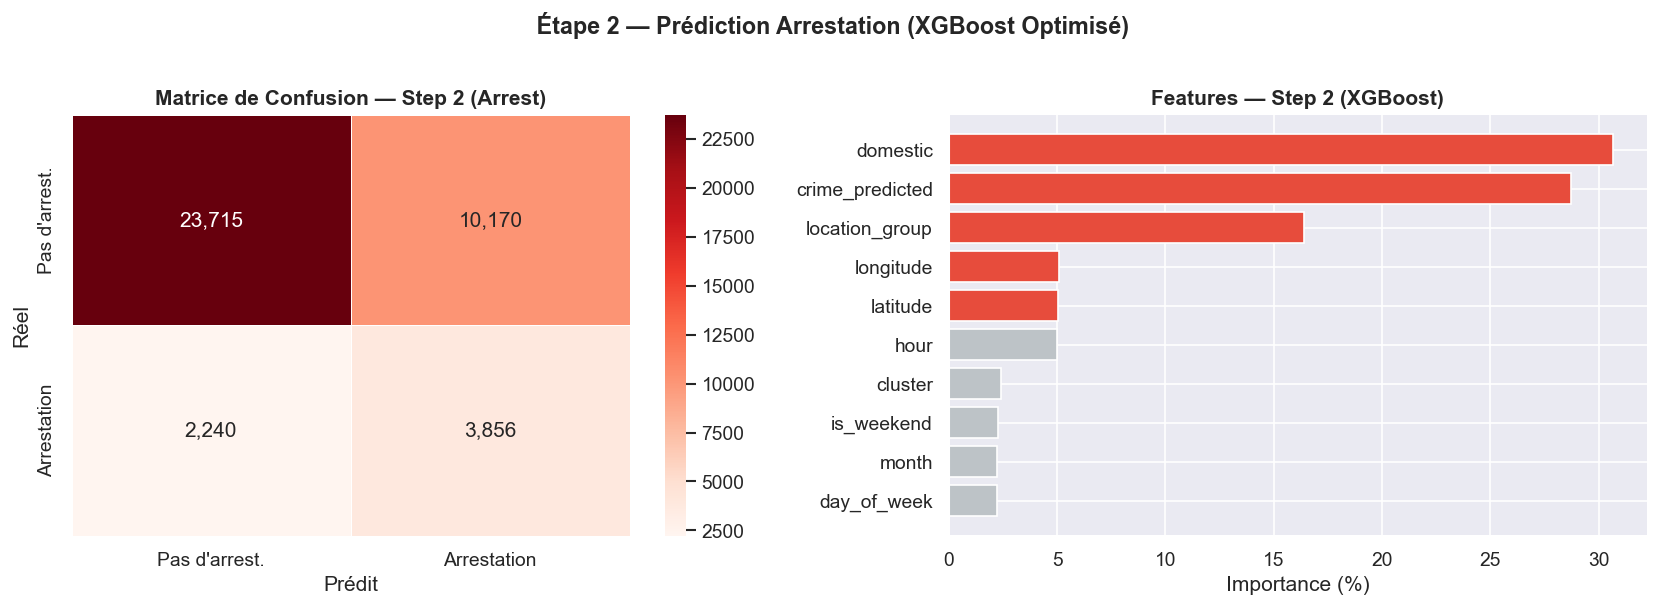

In [15]:
# ── VIZ : Confusion matrix Step 2 + Feature importances ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm2 = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm2, annot=True, fmt=',', cmap='Reds', ax=axes[0],
            xticklabels=["Pas d'arrest.","Arrestation"],
            yticklabels=["Pas d'arrest.","Arrestation"],
            linewidths=0.5)
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
axes[0].set_title('Matrice de Confusion — Step 2 (Arrest)', fontweight='bold')

fi2 = pd.Series(xgb_best.feature_importances_, index=FEAT_STEP2).sort_values()
col2 = ['#e74c3c' if v > fi2.median() else '#bdc3c7' for v in fi2.values]
axes[1].barh(fi2.index, fi2.values*100, color=col2, edgecolor='white')
axes[1].set_xlabel('Importance (%)')
axes[1].set_title('Features — Step 2 (XGBoost)', fontweight='bold')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle(' Étape 2 — Prédiction Arrestation (XGBoost Optimisé)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('viz_06_step2_xgb.png', bbox_inches='tight'); plt.show()


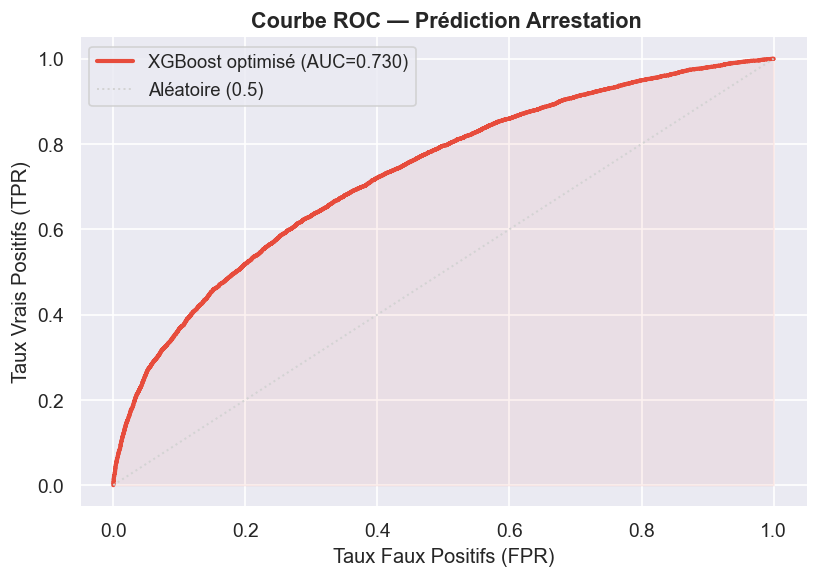

In [16]:
# ── VIZ : Courbe ROC Step 2 ──
fpr, tpr, _ = roc_curve(y2_test, y2_prob)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'XGBoost optimisé (AUC={auc_s2:.3f})')
ax.plot([0,1],[0,1], color='lightgray', linestyle=':', lw=1.2, label='Aléatoire (0.5)')
ax.fill_between(fpr, tpr, alpha=0.07, color='#e74c3c')
ax.set_xlabel('Taux Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux Vrais Positifs (TPR)', fontsize=12)
ax.set_title(' Courbe ROC — Prédiction Arrestation', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('viz_07_roc.png', bbox_inches='tight'); plt.show()


##  4 — Test du Pipeline Complet (End-to-End)

On simule un **vrai scénario** : on donne uniquement le contexte (heure, lieu, coordonnées, domestic) et le pipeline prédit d'abord le type de crime, puis si une arrestation est probable.


In [17]:
def predict_pipeline(latitude, longitude, hour, day_of_week, month,
                     is_weekend, domestic, location_group_val):
    """
    Pipeline complet :
    1. K-Means  → identifier la zone géographique
    2. RF       → prédire le type de crime
    3. XGBoost  → prédire l'arrestation
    """
    # Step 0 — Zone K-Means
    coord_scaled = scaler_kmeans.transform([[latitude, longitude]])
    cluster_pred = kmeans.predict(coord_scaled)[0]

    # Step 1 — Type de crime
    x_step1 = pd.DataFrame([{
        'latitude': latitude, 'longitude': longitude,
        'hour': hour, 'day_of_week': day_of_week, 'month': month,
        'is_weekend': is_weekend, 'cluster': cluster_pred,
        'location_group': location_group_val
    }])[FEAT_STEP1]
    crime_pred_encoded = rf_crime.predict(x_step1)[0]
    crime_pred_label   = le_crime.inverse_transform([crime_pred_encoded])[0]
    crime_pred_proba   = rf_crime.predict_proba(x_step1)[0].max()

    # Step 2 — Arrestation
    x_step2 = pd.DataFrame([{
        'latitude': latitude, 'longitude': longitude,
        'hour': hour, 'day_of_week': day_of_week, 'month': month,
        'is_weekend': is_weekend, 'domestic': domestic,
        'cluster': cluster_pred, 'location_group': location_group_val,
        'crime_predicted': crime_pred_encoded
    }])[FEAT_STEP2]
    arrest_pred  = xgb_best.predict(x_step2)[0]
    arrest_proba = xgb_best.predict_proba(x_step2)[0][1]

    return {
        'zone':         f'Cluster {cluster_pred} — {LABELS[cluster_pred]}',
        'crime_prédit': crime_pred_label,
        'confiance_crime': f'{crime_pred_proba*100:.1f}%',
        'arrestation':  ' OUI' if arrest_pred == 1 else ' NON',
        'proba_arrest': f'{arrest_proba*100:.1f}%',
    }

# ── TEST 1 : Agression domestique en journée (devrait → arrestation) ──
print('='*55)
print('TEST 1 — Agression domestique, 14h, résidence, West Side')
print('='*55)
r1 = predict_pipeline(41.875, -87.720, hour=14, day_of_week=1,
                      month=6, is_weekend=0, domestic=1, location_group_val=1)
for k, v in r1.items(): print(f'  {k:<20} : {v}')

# ── TEST 2 : Vol en pleine nuit, rue, Downtown ──
print()
print('='*55)
print('TEST 2 — Nuit, 3h, rue, Downtown (devrait → pas d\'arrestation)')
print('='*55)
r2 = predict_pipeline(41.882, -87.628, hour=3, day_of_week=5,
                      month=11, is_weekend=1, domestic=0, location_group_val=0)
for k, v in r2.items(): print(f'  {k:<20} : {v}')

# ── TEST 3 : Zone drogue, journée ──
print()
print('='*55)
print('TEST 3 — Après-midi, espace public, zone Narcotics')
print('='*55)
r3 = predict_pipeline(41.870, -87.715, hour=15, day_of_week=2,
                      month=4, is_weekend=0, domestic=0, location_group_val=4)
for k, v in r3.items(): print(f'  {k:<20} : {v}')


TEST 1 — Agression domestique, 14h, résidence, West Side
  zone                 : Cluster 2 — Zone C·West
  crime_prédit         : OTHER OFFENSE
  confiance_crime      : 14.0%
  arrestation          :  NON
  proba_arrest         : 45.5%

TEST 2 — Nuit, 3h, rue, Downtown (devrait → pas d'arrestation)
  zone                 : Cluster 0 — Zone A·Downtown
  crime_prédit         : OTHER
  confiance_crime      : 19.3%
  arrestation          :  OUI
  proba_arrest         : 60.3%

TEST 3 — Après-midi, espace public, zone Narcotics
  zone                 : Cluster 2 — Zone C·West
  crime_prédit         : NARCOTICS
  confiance_crime      : 16.8%
  arrestation          :  OUI
  proba_arrest         : 58.8%


##  5 — Insights & Conclusions

In [18]:
print('='*65)
print('   INSIGHTS PRINCIPAUX')
print('='*65)

# Insight 1
arrest_by_crime = df.groupby('crime_cat')['arrest'].mean().sort_values(ascending=False)
print(f'\n INSIGHT 1 — Le type de crime (prédit Step 1) est le facteur #1')
print(f'   Plus fort taux d\'arrestation :')
for c, r in arrest_by_crime.head(3).items():
    print(f'     {c:<25} → {r*100:.1f}%')
print(f'   Plus faible taux :')
for c, r in arrest_by_crime.tail(3).items():
    print(f'     {c:<25} → {r*100:.1f}%')
gap = arrest_by_crime.iloc[0] / max(arrest_by_crime.iloc[-1], 0.01)
print(f'   → Écart max/min : {gap:.1f}x')

# Insight 2
hour_arrest = df.groupby('hour')['arrest'].mean()
night_rate  = df[df['hour'].between(0, 5)]['arrest'].mean()
day_rate    = df[df['hour'].between(10,16)]['arrest'].mean()
print(f'\n INSIGHT 2 — Pattern horaire fort sur les arrestations')
print(f'   Nuit (0h–5h)     : {night_rate*100:.1f}% d\'arrestations')
print(f'   Journée (10h–16h): {day_rate*100:.1f}% d\'arrestations')
print(f'   → Différence : {abs(day_rate-night_rate)*100:.1f}pts — crimes de nuit moins résolus')

# Insight 3
arrest_cl = df.groupby('cluster')['arrest'].mean()
best_cl   = arrest_cl.idxmax()
worst_cl  = arrest_cl.idxmin()
print(f'\n INSIGHT 3 — La zone géographique reflète le profil de criminalité')
print(f'   Cluster {best_cl} ({LABELS[best_cl]}) : {arrest_cl[best_cl]*100:.1f}% → dominé par Narcotics')
print(f'   Cluster {worst_cl} ({LABELS[worst_cl]}) : {arrest_cl[worst_cl]*100:.1f}% → dominé par Theft/Fraud')

print(f'\n RÉSUMÉ PIPELINE :')
print(f'   K-Means Step 0  : 5 zones géographiques identifiées')
print(f'   RF      Step 1  : {acc_s1*100:.1f}% accuracy — Prédiction type de crime')
print(f'   XGBoost Step 2  : {acc_s2*100:.1f}% accuracy — Prédiction arrestation (AUC {auc_s2:.3f})')
print(f'\n Pipeline complet : contexte → type de crime → probabilité d\'arrestation')


   INSIGHTS PRINCIPAUX

 INSIGHT 1 — Le type de crime (prédit Step 1) est le facteur #1
   Plus fort taux d'arrestation :
     NARCOTICS                 → 94.1%
     OTHER                     → 35.3%
     CRIMINAL TRESPASS         → 32.8%
   Plus faible taux :
     BURGLARY                  → 3.7%
     MOTOR VEHICLE THEFT       → 3.3%
     DECEPTIVE PRACTICE        → 2.8%
   → Écart max/min : 33.6x

 INSIGHT 2 — Pattern horaire fort sur les arrestations
   Nuit (0h–5h)     : 12.5% d'arrestations
   Journée (10h–16h): 15.7% d'arrestations
   → Différence : 3.3pts — crimes de nuit moins résolus

 INSIGHT 3 — La zone géographique reflète le profil de criminalité
   Cluster 2 (Zone C·West) : 20.5% → dominé par Narcotics
   Cluster 3 (Zone D·South) : 11.5% → dominé par Theft/Fraud

 RÉSUMÉ PIPELINE :
   K-Means Step 0  : 5 zones géographiques identifiées
   RF      Step 1  : 24.2% accuracy — Prédiction type de crime
   XGBoost Step 2  : 69.0% accuracy — Prédiction arrestation (AUC 0.730)

 

##  6 — Sauvegarde

In [19]:
joblib.dump(rf_crime,     'rf_crime_type.pkl')
joblib.dump(xgb_best,     'xgb_arrest.pkl')
joblib.dump(kmeans,       'kmeans_chicago.pkl')
joblib.dump(scaler_kmeans,'scaler_kmeans.pkl')
joblib.dump(le_crime,     'label_encoder_crime.pkl')

print(' Modèles sauvegardés :')
print('   rf_crime_type.pkl   — Random Forest (Step 1 : type de crime)')
print('   xgb_arrest.pkl      — XGBoost optimisé (Step 2 : arrestation)')
print('   kmeans_chicago.pkl  — K-Means (Step 0 : zone)')
print()
print(' Visualisations :')
for f in sorted(os.listdir('.')):
    if f.startswith('viz_') and f.endswith('.png'):
        print(f'   {f}')


 Modèles sauvegardés :
   rf_crime_type.pkl   — Random Forest (Step 1 : type de crime)
   xgb_arrest.pkl      — XGBoost optimisé (Step 2 : arrestation)
   kmeans_chicago.pkl  — K-Means (Step 0 : zone)

 Visualisations :
   viz_01_top15.png
   viz_02_eda.png
   viz_03_elbow.png
   viz_04_kmeans.png
   viz_05_step1_rf.png
   viz_06_step2_xgb.png
   viz_07_roc.png
